# Exploration de l'univers S&P 500

## 0. Importation des librairies

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go
from tqdm import tqdm


import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("yfinance").setLevel(logging.CRITICAL)

## 1. Data Loading

In [2]:
universe = pd.read_csv('S&P 500 Historical Components.csv')
universe["date"] = pd.to_datetime(universe["date"])
universe.head()

,date,tickers
0,1996-01-02,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
1,1996-01-03,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
2,1996-01-04,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
3,1996-01-10,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
4,1996-01-11,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."


In [3]:
universe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2705 entries, 0 to 2704
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     2705 non-null   datetime64[ns]
 1   tickers  2705 non-null   object        
dtypes: datetime64[ns](1), object(1)
memory usage: 42.4+ KB


## 3. Data Explo

In [4]:
universe["nb_tickers"] = universe["tickers"].apply(lambda x: len(x.split(",")))
universe["change"] = universe["nb_tickers"].diff()
universe.head()

,date,tickers,nb_tickers,change
0,1996-01-02,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...",487,NaN
1,1996-01-03,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...",487,0.0
2,1996-01-04,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...",487,0.0
3,1996-01-10,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...",487,0.0
4,1996-01-11,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...",487,0.0


In [5]:
px.line(universe, x='date', y='nb_tickers', title='Number of Tickers in S&P 500 Over Time')

In [6]:
px.scatter(universe, x='date', y='change', title='Change in Number of Tickers in S&P 500 Over Time')

In [7]:
example = universe["tickers"].iloc[0].split(",")
print(f"Example tickers from {universe['date'].iloc[0]}: {example[:10]}")

Example tickers from 1996-01-02 00:00:00: ['AAL', 'AAMRQ', 'AAPL', 'ABI', 'ABS', 'ABT', 'ABX', 'ACKH', 'ACV', 'ADM']


In [8]:
yf.Ticker(example[0]).history(period="5d")

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-04-07 00:00:00-04:00,10.81,10.85,10.55,10.81,56698500,0.0,0.0
2026-04-08 00:00:00-04:00,12.03,12.20,11.38,11.41,100666000,0.0,0.0
2026-04-09 00:00:00-04:00,11.32,11.50,11.13,11.37,36844200,0.0,0.0
2026-04-10 00:00:00-04:00,11.45,11.49,11.24,11.32,31912500,0.0,0.0
2026-04-13 00:00:00-04:00,11.00,11.23,10.91,11.23,43883600,0.0,0.0


## 4. Obtention des dates limites de présence dans l'indice S&P 500 pour un ticker 

In [9]:
def get_date_margins_in_universe(ticker):
    is_in = universe["tickers"].apply(lambda s: ticker in s.split(","))

    starts = universe.loc[
        is_in & ~is_in.shift(1, fill_value=False), "date"
    ].tolist()

    ends = universe.loc[
        is_in & ~is_in.shift(-1, fill_value=False), "date"
    ].tolist()

    return [[start, end] for start, end in zip(starts, ends)]

# keep this for compatibility with later cells if needed
def get_year_margins_in_universe(ticker):
    return [[s.year, e.year] for s, e in get_date_margins_in_universe(ticker)]

marges_aal = get_date_margins_in_universe("SOLS")
marges_aal

[[Timestamp('2025-10-30 00:00:00'), Timestamp('2025-12-11 00:00:00')]]

In [17]:
ticker = "AAPL"
marges = get_year_margins_in_universe(ticker)
print(f"{ticker} was in the S&P 500 during the following periods:")
for start, end in marges:
    print(f" - {start} to {end}")

prices_data = yf.Ticker(ticker).history(start="1996-01-01", end="2025-12-31")
fig = go.Figure()
fig.add_trace(go.Scatter(x=prices_data.index, y=prices_data["Close"], mode="lines", name=f"{ticker} Close Price"))
for start, end in marges:
    fig.add_vrect(x0=datetime(start, 1, 1), x1=datetime(end, 1, 1), fillcolor="LightSalmon", opacity=0.3, line_width=0)
fig.update_layout(title=f"{ticker} Price with S&P 500 Inclusion Periods", xaxis_title="Date", yaxis_title="Price (USD)")
fig.show()

AAPL was in the S&P 500 during the following periods:
 - 1996 to 2026


## 5. Filtration de l'univers en fonction de la disponibilité des données

In [11]:
def compute_universe_filtered(universe):
    filtered_universe = []
    tickers_done = set()
    
    for idx, row in tqdm(universe.iterrows(), total=len(universe), desc="Filtering Universe"):
        tickers = row["tickers"].split(",")
        tickers = [t for t in tickers if t not in tickers_done]
        
        for ticker in tickers:
            margins = get_date_margins_in_universe(ticker)
            if not margins:
                continue
            
            # Récupère l'historique complet une seule fois
            min_date = min(start for start, end in margins)
            max_date = max(end for start, end in margins)
            try:
                full_data = yf.Ticker(ticker).history(start=min_date, end=max_date)
                # Convertir l'index en datetime naive pour éviter les erreurs de timezone
                if not full_data.empty and isinstance(full_data.index, pd.DatetimeIndex) and full_data.index.tz is not None:
                    full_data.index = full_data.index.tz_localize(None)
            except Exception as e:
                print(f"Erreur pour {ticker}: {e}")
                continue
            
            # Vérifie chaque période
            for start, end in margins:
                period_data = full_data.loc[start:end]
                if not period_data.empty:
                    filtered_universe.append({
                        "ticker": ticker,
                        "start": start,
                        "end": end,
                        # Optionnel : stocke seulement la longueur au lieu du DataFrame
                        "data_length": len(period_data)
                    })
        
        tickers_done.update(tickers)
    
    return pd.DataFrame(filtered_universe)
filtered_universe = compute_universe_filtered(universe)
filtered_universe.head()

Filtering Universe:   0%|          | 0/2705 [00:00<?, ?it/s]

Filtering Universe: 100%|██████████| 2705/2705 [05:09<00:00,  8.74it/s]  


,ticker,start,end,data_length
0,AAL,2015-03-23,2024-07-08,2338
1,AAPL,1996-01-02,2026-01-14,7558
2,ABT,1996-01-02,2026-01-14,7558
3,ADM,1996-01-02,2026-01-14,7558
4,ADP,1996-01-02,2026-01-14,7558


In [15]:
filtered_universe = filtered_universe[filtered_universe["data_length"] > 50]
filtered_universe.to_csv("filtered_universe.csv", index=False)

In [16]:
filtered_universe.sort_values("data_length").head()

,ticker,start,end,data_length
690,HOOD,2025-09-22,2026-01-14,79
688,APP,2025-09-22,2026-01-14,79
689,EME,2025-09-22,2026-01-14,79
606,VNT,2020-10-12,2021-02-12,85
687,IBKR,2025-08-28,2026-01-14,95


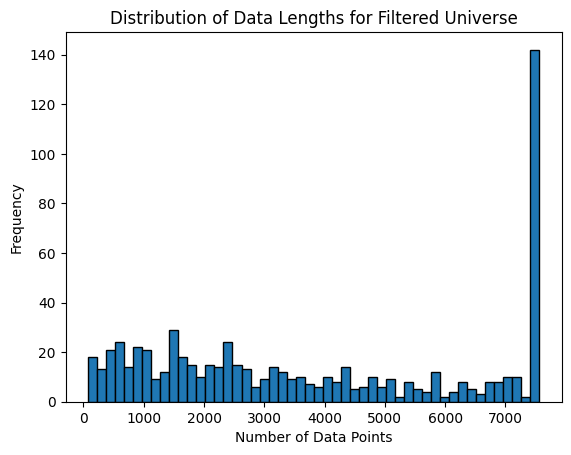

In [14]:
plt.hist(filtered_universe["data_length"], bins=50, edgecolor="k")
plt.title("Distribution of Data Lengths for Filtered Universe")
plt.xlabel("Number of Data Points")
plt.ylabel("Frequency")
plt.show()

## 6. Enregistrement des données de marchés pour notre univers filtré

In [ ]:
def cache_data(universe):
    for idx, row in tqdm(universe.iterrows(), total=len(universe), desc="Caching Data"):
        ticker = row["ticker"]
        start = row["start"]
        end = row["end"]
        
        try:
            data = yf.Ticker(ticker).history(start=start, end=end, adjusted=True)
            if not data.empty:
                data.to_csv(f"data_cache/{ticker}_{start.year}_{end.year}.csv")
        except Exception as e:
            print(f"Erreur pour {ticker}: {e}")
cache_data(filtered_universe)

Caching Data: 100%|██████████| 681/681 [02:14<00:00,  5.06it/s]


In [4]:
filtered_universe = pd.read_csv("filtered_universe.csv")

In [5]:
filtered_universe.value_counts("GICS Sector")

GICS Sector
Industrials               80
Information Technology    74
Financials                73
Health Care               61
Consumer Discretionary    47
Consumer Staples          36
Utilities                 32
Real Estate               31
Materials                 26
Communication Services    24
Energy                    24
Name: count, dtype: int64

In [6]:
filtered_universe_missing_sectors = pd.read_csv("filtered_universe_missing_sectors.csv")
for ticker in tqdm(filtered_universe_missing_sectors["ticker"], desc="Filling Missing Sectors"):
    try:
        info = yf.Ticker(ticker).info
        sector = info.get("sector", "Unknown")
        filtered_universe.loc[filtered_universe["ticker"] == ticker, "GICS Sector"] = sector
    except Exception as e:
        print(f"Erreur pour {ticker}: {e}")

Filling Missing Sectors: 100%|██████████| 173/173 [00:26<00:00,  6.41it/s]
